### CV 노드02 퀘스트 
## <center>인물모드 사진 만들기</center>
----

```text
segmentation을 활용하여 인물모드 사진을 만든다. 

순서는 다음과 같다
```

In [1]:
!pip install opencv-python pixellib

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 41.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 106.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 50.0 MB/s eta 0:00:0000:0100:01
  DEPRECATION: Building 'fvcore' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` op

# 라이브러리 import 

In [4]:
import os
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)
print(np.__version__)

4.13.0
2.2.6


# 인물모드에 사용할 사진 읽어오기 

원본 고양이 이미지 크기: (1280, 853, 3)
원본 고양이 이미지 크기: (4128, 5464, 3)
원본 사람  이미지 크기: (5712, 4284, 3)
배경(사막) 이미지 크기: (1969, 2953, 3)


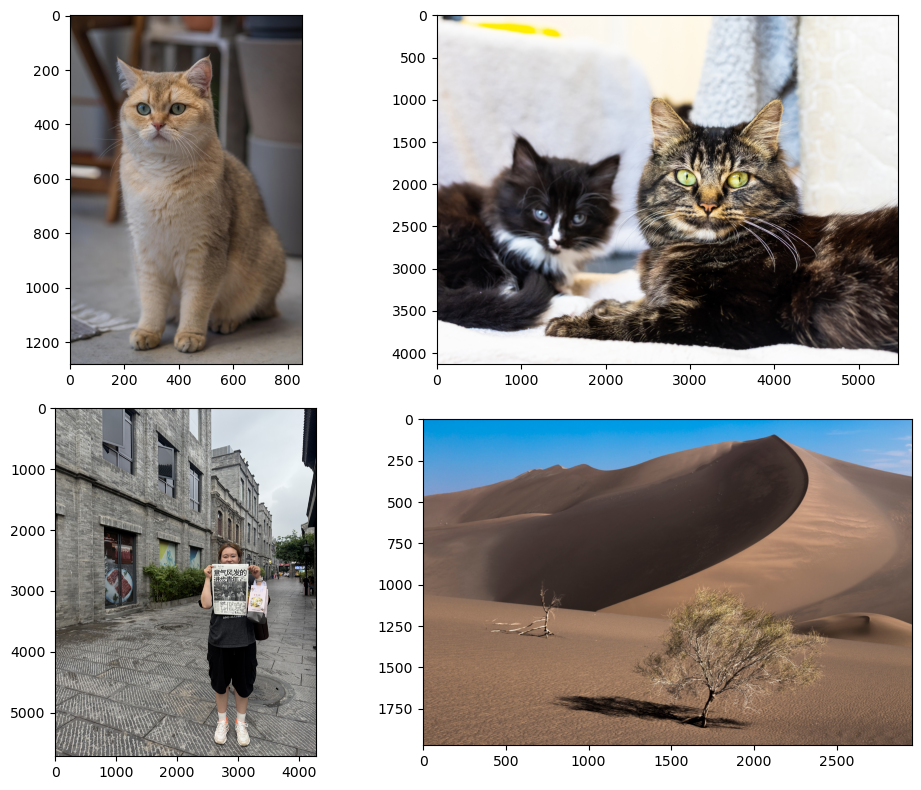

In [51]:
# 환경변수를 가져와서 home_dir 변수에 저장 
home_dir = os.getenv("HOME")

# 고양이와 사막, 사람 사진 path들 변수에 저장 
cat_img_path = os.path.join(home_dir, "work/cat_desert_human/cat.jpg")
cat2_img_path = os.path.join(home_dir, "work/cat_desert_human/cat2.jpg")
desert_img_path = os.path.join(home_dir, "work/cat_desert_human/desert.jpg")
human_img_path = os.path.join(home_dir, "work/cat_desert_human/human.jpeg")

# cv2를 활용하여 이미지를 불러옴(rgb로 유형 변경) 
cat_img_ori = cv2.imread(cat_img_path)
cat2_img_ori = cv2.imread(cat2_img_path)
human_img_ori = cv2.imread(human_img_path)
desert_img_ori = cv2.imread(desert_img_path)

cat_img_rgb = cv2.cvtColor(cat_img_ori, cv2.COLOR_BGR2RGB)
cat2_img_rgb = cv2.cvtColor(cat2_img_ori, cv2.COLOR_BGR2RGB)
human_img_rgb = cv2.cvtColor(human_img_ori, cv2.COLOR_BGR2RGB)
desert_img_rgb = cv2.cvtColor(desert_img_ori, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img_rgb.shape}")   # 원본 고양이 이미지 크기: (1280, 853, 3)
print(f"원본 고양이 이미지 크기: {cat2_img_rgb.shape}")   # 원본 고양이 이미지 크기: (3000, 2122, 3)
print(f"원본 사람  이미지 크기: {human_img_rgb.shape}")  # 원본 사람 이미지 크기: (1969, 2953, 3)
print(f"배경(사막) 이미지 크기: {desert_img_rgb.shape}")  # 배경(사막) 이미지 크기: (1969, 2953, 3)

plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
plt.imshow(cat_img_rgb)

plt.subplot(2, 2, 2)
plt.imshow(cat2_img_rgb)

plt.subplot(2, 2, 3)
plt.imshow(human_img_rgb)

plt.subplot(2, 2, 4)
plt.imshow(desert_img_rgb)

plt.tight_layout()
plt.show()

# 모델 적용 및 추론

In [52]:
# deeplabv3_resnet101 의 미리 학습된 모델 가져와서 사용 
model = deeplabv3_resnet101(pretrained=True).eval()

# 학습시 사용된 것과 규격이 같아야 하므로, Resize()로 크기 고정 
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 
    T.ToTensor(),
])

rgb_images = [cat_img_rgb, cat2_img_rgb, human_img_rgb]

# 추론 결과 저장할 빈 리스트 
output_predictions_list = []

# 기울기 계산 제외한, 추론 모드 수행 
with torch.no_grad():
    for i, img in enumerate(rgb_images):

        # 배치 차원을 추가하기 위해서 .unsqueeze(0)로 텐서 맨 앞에 한 자리 추가 
        # deeplabv3_resnet101 모델에 입력하기 위해선 배치 차원이 필수 
        input_tensor = transform(img).unsqueeze(0)
        
        # 모델 추론
        output = model(input_tensor)["out"][0]
        
        # 마스크 변환 (Argmax -> Byte -> CPU -> Numpy)
        output_predictions = output.argmax(0).byte().cpu().numpy()
        
        # 결과를 리스트에 저장
        output_predictions_list.append(output_predictions)
        
        print(f"[{i+1}번째 이미지] 추론 마스크 크기: {output_predictions.shape}")


/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[1번째 이미지] 추론 마스크 크기: (520, 520)
[2번째 이미지] 추론 마스크 크기: (520, 520)
[3번째 이미지] 추론 마스크 크기: (520, 520)


In [53]:
# 앞선 셀에서 deeplabv3_resnet101 모델에 입력하기 위해 (520,520)에 맞게 줄임
# 원본에 적용하기 위해서 마스크를 원본 크기로 Resize

# 원본 크기로 복원된 마스크들을 저장할 리스트
resized_predictions_list = []

# zip을 이용해 원본 이미지와 추론 마스크를 매칭하여 반복문 실행
for i, (img, pred) in enumerate(zip(rgb_images, output_predictions_list)):
    
    # 각 이미지의 원본 크기(가로, 세로)를 가져와 Resize 수행
    output_predictions_resized = cv2.resize(
        pred, 
        (img.shape[1], img.shape[0]), # (Width, Height) 순서
        interpolation=cv2.INTER_NEAREST
    )
    
    # 결과를 최종 리스트에 추가
    resized_predictions_list.append(output_predictions_resized)
    
    print(f"[{i+1}번째 이미지 마스크 복원 완료]")
    print(f"  - 원본 크기: {img.shape[1]}x{img.shape[0]}")
    # 가로, 세로 채널 순으로 확인용 출력 (.shape는 행, 열 즉 세로, 가로 순)
    print(f"  - 결과 shape (H, W): {output_predictions_resized.shape}\n")


[1번째 이미지 마스크 복원 완료]
  - 원본 크기: 853x1280
  - 결과 shape (H, W): (1280, 853)

[2번째 이미지 마스크 복원 완료]
  - 원본 크기: 5464x4128
  - 결과 shape (H, W): (4128, 5464)

[3번째 이미지 마스크 복원 완료]
  - 원본 크기: 4284x5712
  - 결과 shape (H, W): (5712, 4284)



In [54]:
# output에 어떤 클랙스가 예측되었는지 확인 

#pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]

for i, mask in enumerate(resized_predictions_list):
    print(f"[{i+1}번째 이미지 결과]")

    # 현재 마스크 이미지에서 고유한 클래스 ID cncnf
    unique_classes = np.unique(mask)
    print(f"예측된 클래스 ID: {unique_classes}")

    # 각 클래스 ID에 매칭되는 라벨 이름 출력
    print("  - 검출된 객체 라벨:")
    for class_id in unique_classes:
        # 혹시 모를 인덱스 에러를 방지하기 위해 안전하게 가져오기
        if class_id < len(LABEL_NAMES):
            print(f"    * {LABEL_NAMES[class_id]}")
        else:
            print(f"    * Unknown ID ({class_id})")
    print("-" * 40)


[1번째 이미지 결과]
예측된 클래스 ID: [0 8]
  - 검출된 객체 라벨:
    * background
    * cat
----------------------------------------
[2번째 이미지 결과]
예측된 클래스 ID: [0 8]
  - 검출된 객체 라벨:
    * background
    * cat
----------------------------------------
[3번째 이미지 결과]
예측된 클래스 ID: [ 0 15]
  - 검출된 객체 라벨:
    * background
    * person
----------------------------------------


output에서 예측된 클래스는 0번 background와 8번 cat이다. 
그렇다면 고양이 이미지만 확인하기 위해서는 target class id는 1, 나머지는 0이 되게 한다. 

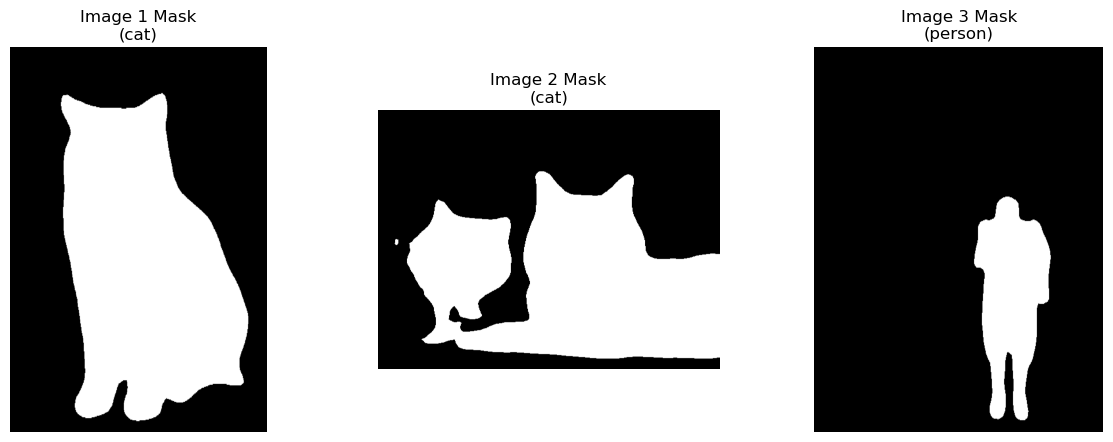

In [55]:
plt.figure(figsize=(15, 5))

# 원본 크기 복원 마스크 리스트를 순회
for i, mask in enumerate(resized_predictions_list):
    
    # 현재 마스크 이미지에서 고유 클래스 ID들 추출
    unique_classes = np.unique(mask)
    
    # 타겟 클래스 선정 (현재 이미지에서 가장 큰 ID값 추출)
    target_class_id = unique_classes[-1]
    
    # 해당 클래스만 1(True), 나머지는 0(False)으로 이진화 후 255 곱하기
    seg_map = (mask == target_class_id)
    img_mask = seg_map.astype(np.uint8) * 255
    
    # 1행 3열 격자 중 (i+1)번째 자리에 그림 그리기
    plt.subplot(1, 3, i + 1)
    plt.imshow(img_mask, cmap='gray')
    
    # 타이틀에 몇 번째 이미지인지와 타겟 라벨 이름 표시하기
    label_name = LABEL_NAMES[target_class_id] if target_class_id < len(LABEL_NAMES) else "Unknown"
    plt.title(f"Image {i+1} Mask\n({label_name})")
    plt.axis('off') # 격자 테두리 숨기기 (선택 사항)


# 이미지 segmentation - shallow focus

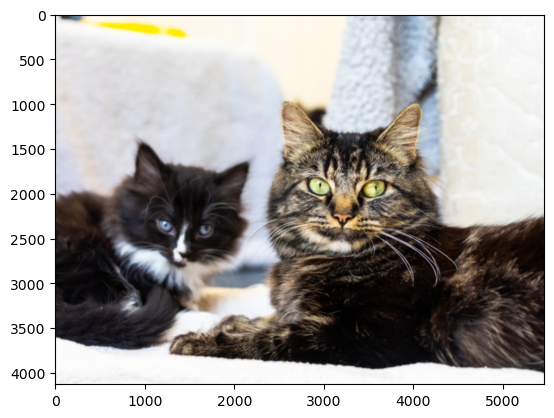

In [44]:
# 배경 흐리게 하기 - blur() 함수 사용 
img_orig_blur = cv2.blur(cat3_img_ori, (13, 13))

# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(img_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()

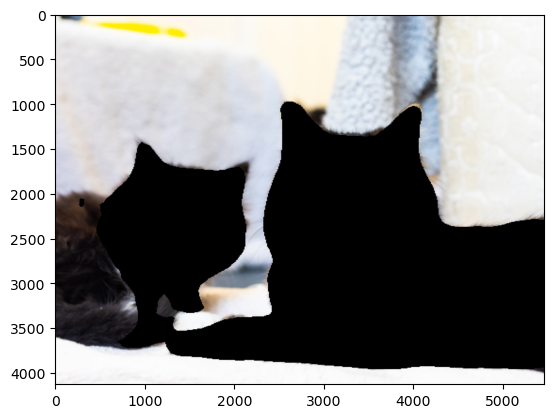

In [45]:
# 흐려진 이미지에서 세그멘테이션 마스크를 이용해서 배경만 추출한다. 

# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_GRAY2BGR: GRAY에서 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (GRAY 형식을 BGR 형식으로 변경)
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지가 반전됨. 배경이 0 고양이가 255 였으나
# 연산을 하고 나면 배경은 255 고양이는 0. 
img_bg_mask = cv2.bitwise_not(img_mask_color)

# cv2.bitwise_and()을 사용하면 배경만 있는 영상을 얻을 수 있음.
# 0과 어떤 수를 bitwise_and 연산을 해도 0이 되기 때문에
# 고양이가 0인 경우에는 고양이가 있던 모든 픽셀이 0이 된다. 결국 고양이가 사라지고 배경이 남는다. 
img_bg_blur = cv2.bitwise_and(img_orig_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

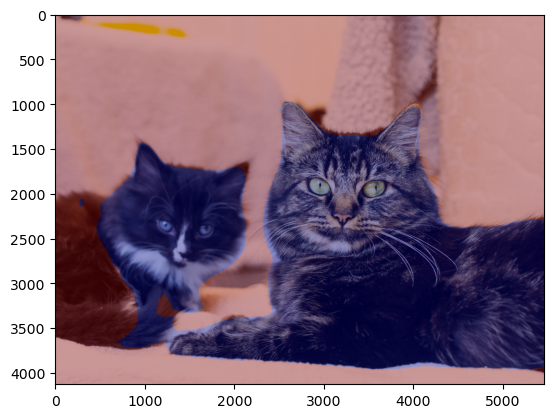

In [59]:
#원본 이미지와 마스크를 적당히 합쳐 세그멘테이션이 잘 되었는지 확인 
color_mask = cv2.applyColorMap(img_bg_mask, cv2.COLORMAP_JET)
img_show = cv2.addWeighted(cat3_img_ori, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

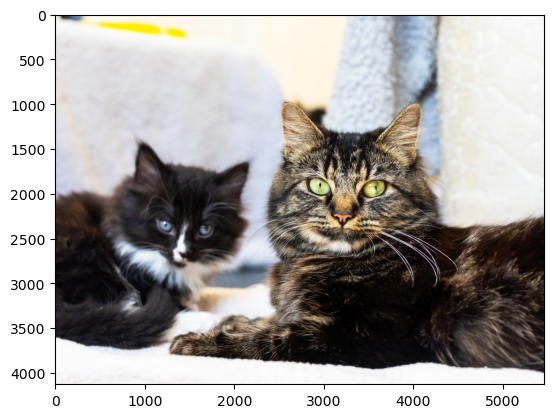

In [46]:
# 흐린 배경과 원본 영상 합성

# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고
# 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat = np.where(img_mask_color==255, cat3_img_ori, img_bg_blur)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

<b>문제점 확인</b> : 전경(Foreground)에 위치한 성묘의 경우 인스턴스 분할(Instance Segmentation)이 정확히 수행되었으나, 배경에 위치한 새끼 고양이의 경우 몸통 일부 영역이 고양이 객체로 인식되지 못하고 탈락하는 현상이 발생함.
이로 인해 후처리 단계에서 배경뿐만 아니라 새끼 고양이의 미인식된 신체 부위까지 함께 블러(Blur) 처리되는 시각적 오류가 발생함.  

<b>원인 분석</b> :   
세그멘테이션 모델이 새끼 고양이의 일부를 놓친 이유는 크게 2가지 추정해 볼 수 있다. 
+ 객체 스케일 및 깊이 문제 (Scale & Depth Variation): 전경(Foreground)에 크게 위치한 성묘에 비해, 새끼 고양이는 상대적으로 크기가 작고 원경(Background)에 위치해 있다. CNN 기반 모델의 특성상, 레이어가 깊어지며 피처 맵(Feature Map)의 해상도가 낮아질 때 크기가 작고 멀리 있는 객체의 세부적인 경계 정보가 손실되었을 가능성이 크다. 
+ 배경 및 주변 객체와의 모호성(조도 및 색상 유사성) : 이미지 속 새끼 고양이는 전반적으로 어두운 털을 가지고 있으나, 목 주변에만 부분적으로 흰색 털이 분포되어 있다.
  세그멘테이션 결과를 살펴보면, 정확히 이 흰색 털 영역을 기점으로 인식이 끊긴 것을 확인할 수 있다. 이는 목 부위의 밝은 털이 뒤쪽의 밝은 배경(이불/소품)과 유사하여 모델이 이를 객체의 끝(경계)으로 오인했고, 그 결과 아래쪽의 나머지 몸통 영역을 고양이 객체에서 누락시키는 연쇄적인 오류를 유발한 것으로 추정된다.

<center><img src="./img/Q-2-1.png" width=500></center>

<b>해결 방안</b> :   
1. 밝은 털-배경 모호성 해결을 위한 방안
목 주변의 흰색 털이 배경에 묻혀 경계선이 끊어진 문제는 색상 대비(Contrast) 개선과 미세 경계(Edge) 복원 기술로 해결할 수 있을 것으로 보인다.
    + Contrast Limited Adaptive Histogram Equalization (CLAHE) 전처리 적용
        + 이미지 전체가 아닌, 지역적으로 명암비를 개선하는 CLAHE 알고리즘을 전처리 단계에 도입한다면, 새끼고양이의 흰색털과 밝은 배경 사이의 명도 차이를 특대화 하여 모델이 두 영역을 다른 객체로 구분하도록 돕는다.
    + 디커플드 세그멘테이션(Decoupled Segmentation) 또는 경계선(Edge) 손실 함수 추가
        + 모델 학습 시 마스크 형태만 학습하는 것이 아니라, 객체의 '경계선(Edge)'을 별도로 예측하도록 하는 Loss를 추가한다. 픽셀의 색상 변화가 미미하더라도 형태학적 경계를 더 날카롭게 잡아내어 목 밑의 몸통까지 연결성을 유지하게 만든다.
2. 작은 스케일 및 정보 손실 해결을 위한 방안
상대적으로 멀리 있고 작아서 피처 맵 단계에서 뭉개진 새끼 고양이의 세부 정보를 살리기 위해서 다중 스케일 제어 기술이 필요할 것으로 보인다.
    + 다중 스케일 추론 (Multi-Scale Inference / Test-Time Augmentation)
        + 이미지를 원본 크기뿐만 아니라 1.5배, 2배 등으로 키워서 모델에 입력한 뒤 결과를 종합(Ensemble)하는 방식. 이미지가 커지면 원경에 있던 작은 새끼 고양이의 피처가 모델 내에서 '큰 객체'처럼 다뤄지므로 세부 형태를 놓치지 않고 잡아낼 수 있다.
    + 고해상도 특징 맵 유지 백본(Backbone) 전환 (예: HRNet, SegFormer)
       + 기존의 U-Net이나 ResNet 계열 백본은 다운샘플링 과정에서 작은 객체의 정보가 소실되기 쉽다. 입력 이미지의 고해상도 해상도를 처음부터 끝까지 병렬로 유지하는 HRNet이나, 글로벌 콘텍스트를 잘 파악하는 트랜스포머 기반의 SegFormer 같은 최신 아키텍처로 변경하면 작은 새끼 고양이의 스케일도 포착할 가능성이 높아진다. 
   

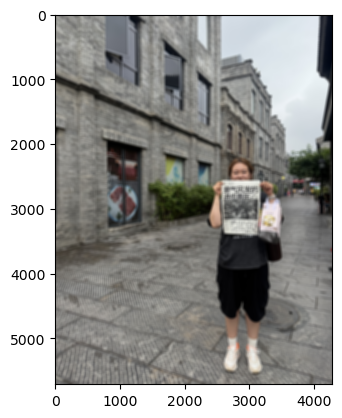

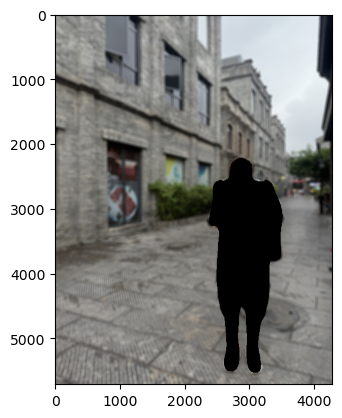

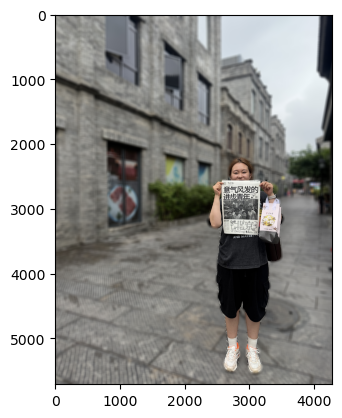

In [57]:
# 사람 이미지에 적용 

# 배경 흐리게 하기 - blur() 함수 사용 
human_orig_blur = cv2.blur(human_img_ori, (50, 50))
plt.imshow(cv2.cvtColor(human_orig_blur, cv2.COLOR_BGR2RGB))
plt.show()


# 흐려진 이미지에서 세그멘테이션 마스크를 이용해서 배경만 추출
human_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
human_bg_mask = cv2.bitwise_not(human_mask_color)
human_bg_blur = cv2.bitwise_and(human_orig_blur, human_bg_mask)
plt.imshow(cv2.cvtColor(human_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

# 흐린 배경과 원본 영상 합성
human_img_concat = np.where(human_mask_color==255, human_img_ori, human_bg_blur)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(human_img_concat, cv2.COLOR_BGR2RGB))
plt.show()

# 이미지 segmenation - 크로마키

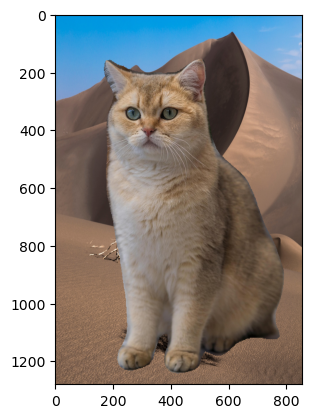

In [32]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(desert_img_rgb, (cat_img_rgb.shape[1], cat_img_rgb.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img_rgb, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

<b>문제점 확인</b> : 고양이 객체의 전반적인 실루엣과 거시적인 형태는 정확히 분할(Segmentation)되었으나, 고양이 외곽선 특유의 미세한 털(Fine hair/Fur) 영역과 배경의 경계면 처리에 한계가 발생함.
픽셀 단위의 미세한 털 구조를 보존하지 못하고 외곽 라인을 따라 마스크가 단순하고 뭉툭하게 생성됨에 따라, 털 사이에 잔존하는 배경이 완벽히 제거되지 못하고 결합되어 인위적이고 어색한 합성 결과물이 도출됨. 

<b>원인 분석</b> :   
+ 이진 마스크(Binary Mask)의 한계 : 오늘 사용한 세그멘테이션 모델은 픽셀을 '고양이(1)' 또는 '배경(0)'으로만 이분법적으로 구분한다. 하지만 동물의 털이나 반투명한 경계는 픽셀 하나에 고양이와 배경이 섞여 있는 경우가 많아, 이진 마스크 구조 자체의 한계로 인해 외곽선이 떡지거나 뭉개지게 된다. 
+ 다운샘플링(Downsampling)으로 인한 고주파 정보 손실 : 모델 내부에서 연산 속도와 콘텍스트 파악을 위해 이미지를 축소 했다가 다시 키우는 과정에서, '얇은 털'과 같은 고주파(High-frequency) 세부 디테일 정보는 손실되기 쉽다. 

<b>해결 방안</b> :   
털 빠짐/외곽선 뭉개짐 문제를 해결하기 위해서는 단순 세그멘테이션 대신, 경계면의 불투명도($\alpha$값)를 0에서 1 사이의 연속적인 값으로 예측하는 디프 매팅(Deep Matting) 모델을 적용하는 것이 좋다. 이를 통해 머리카락이나 동물의 털 사이에 비치는 배경을 분리해낼 수 있다. 

# NOTE
---

```text
오늘은 고양이와 사람 이미지를 가지고 배경을 흐리게 하거나, 크로마키 효과처럼 배경을 다른 이미지로 교체하는 image segmentation 모델을 수행했다. 
단순히 '잘 안된다'에서 그치지 않고, 데이터의 시각적 특성이 모델이 미치는 인과관계를 찾아내기 위해서 노력한 것은 매우 의미있었다. 세그멘테이션 마스크의 이진 분류의 한계를 극복하기 위해서는 어떤 기술을 적용해야 하는지 찾아보는 좋은 시간이었다. 
```
### [마주한 문제점 및 원인 분석]  
#### 이슈 01. 원경의 소형 객체 누락 및 경계선 단절 
+ 현상 : 전경의 성묘는 잘 인식했으나, 왼쪽 뒤편의 새끼 고양이 몸통 일부가 배경으로 오인되어 블러(Blur) 처리되는 현상 발생.
+ 원인 분석:
    + 색상 모호성: 새끼 고양이 목 주변의 '흰색 털'이 뒤쪽의 밝은 배경과 명도 차이가 없어 모델이 객체의 경계로 오인함.
    + 스케일 문제: 원경에 위치하여 피처 맵(Feature Map) 다운샘플링 과정에서 세부 경계 정보가 유실됨.

#### 이슈 02. 외곽 미세 털(Fur) 영역의 단순화 및 배경 잔존
+ 현상: 고양이의 전반적인 거시적 실루엣은 확보했으나, 얇은 털들과 배경이 겹치는 경계면이 뭉툭하게 처리되어 배경이 완벽히 제거되지 못함.
+ 원인 분석: 이진 마스크(Binary Mask)의 이분법적(0 또는 1) 예측 한계와 고주파(High-frequency) 정보 손실로 인해 미세한 구조 표현이 불가능함.

### [향후 해결 방안 모색]
현재 파이프라인은 DeepLabV3-ResNet101 사전 학습 모델을 그대로 활용하는 구조이므로, 모델 내부 레이어를 수정하거나 재학습을 진행하는 데에는 제약이 있었다. 따라서 모델 아키텍처는 유지하되, 입력 전처리 및 출력 후처리 파이프라인을 개선하는 방향으로 다음과 같은 현실적인 해결 방안을 모색하고자 한다. 

(1) 전처리 파트 : 모델 입력 전 명암비 개선 
모델이 입력 이미지는 잘 인식할수 있도록 가공한다. 색상 모호성을 해결하기 위해서 OpenCV 등의 라이브러리를 이용하여 입력 이미지네 CLAHE(명암비 지속 개선 알고리즘)를 적용한 후 모델에 입력한다. 

(2) 추론 파트 : 입력 스케일 다변화 
상대적으로 작은 크기의 새끼 고양이가 유실되는 문제를 해결하기 위해서 원본 이미지 외의 이미지를 1.5배 또는 2.0배 확대한 이미지를 모델이 각각 입력한다. 이후 출력된 마스크들은 다시 원본 사이즈로 리사이즈하여 결합하는 방식을 도입한다면, 객체의 디테일을 복원할 수 있을 것이다. 

(3) 후처리 : 이진 마스크 정제 
DeepLab V3+의 이진 마스크와 원본 이미지를 결합하여 외곽선을 정교화하는 후처리 알고리즘을 추가한다. 픽셀의 변화량을 기반으로, 고양이의 외곽 미세 털 경계를 날카롭게 깎아내어 배경을 제거할 수 있을 것이다. 

